# Assignment No. 4 — Diffusion Models for High-Resolution Image Generation & Reconstruction
**Course:** Generative AI (AI4009) | Spring 2026  
**Platform:** Kaggle (GPU T4 x2)  
**Dataset:** CelebA-HQ 256

## 1. Environment Setup & Imports

In [1]:
# Install required libraries
!pip install -q scikit-image gradio

In [2]:
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid, save_image
from torch.cuda.amp import autocast, GradScaler

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device setup (supports multi-GPU on Kaggle T4x2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU count: {torch.cuda.device_count()}')
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

Using device: cuda
GPU count: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## 2. Configuration

In [12]:
class Config:
    # ── Data Paths ──
    # CelebA-HQ has two folders: train/ and valid/
    # train/ → used for model training (gradient updates)
    # valid/ → used for reconstruction target & PSNR/SSIM evaluation
    TRAIN_DIR      = '/kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/train'
    VALID_DIR      = '/kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/valid'

    IMG_SIZE       = 128          # Use 256 for higher quality (needs more VRAM)
    CHANNELS       = 3

    # Diffusion
    T              = 400          # total diffusion timesteps (200-500 recommended)
    BETA_START     = 1e-4
    BETA_END       = 0.02
    SCHEDULE       = 'cosine'     # 'linear' or 'cosine'

    # Training
    BATCH_SIZE     = 16
    LR             = 2e-4
    EPOCHS         = 10
    GRAD_CLIP      = 1.0
    AMP            = True         # mixed precision
    NUM_WORKERS    = 2

    # U-Net
    MODEL_CHANNELS = 64           # base channel width (64->128->256)
    TIME_EMB_DIM   = 256

    # Misc
    SAVE_DIR       = './outputs'
    CKPT_PATH      = './ddpm_checkpoint.pt'

cfg = Config()
os.makedirs(cfg.SAVE_DIR, exist_ok=True)
print('Config ready.')

Config ready.


## 3. Dataset & DataLoader (Part 1 – Data Preprocessing)

In [13]:
class ImageFolderDataset(Dataset):
    """
    Flat image folder dataset.
    Expects DATA_DIR to contain image files directly (jpg/png/jpeg).
    """
    EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp'}

    def __init__(self, root, img_size=128):
        self.paths = [
            p for p in Path(root).rglob('*')
            if p.suffix.lower() in self.EXTENSIONS
        ]
        assert len(self.paths) > 0, f'No images found in {root}'
        print(f'Found {len(self.paths):,} images in {root}')

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),   # → [-1, 1]
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img)


# ── Train dataset (shuffled, used for gradient updates) ──
train_dataset = ImageFolderDataset(cfg.TRAIN_DIR, cfg.IMG_SIZE)
train_loader  = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)

# ── Valid dataset (no shuffle, used for reconstruction & PSNR/SSIM evaluation) ──
valid_dataset = ImageFolderDataset(cfg.VALID_DIR, cfg.IMG_SIZE)
valid_loader  = DataLoader(
    valid_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
    drop_last=False,
)

print(f'Train images  : {len(train_dataset):,}')
print(f'Valid images  : {len(valid_dataset):,}')
print(f'Train batches : {len(train_loader)}')
print(f'Valid batches : {len(valid_loader)}')

Found 27,000 images in /kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/train
Found 3,000 images in /kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/valid
Train images  : 27,000
Valid images  : 3,000
Train batches : 1687
Valid batches : 188


## 4. Noise Schedule & Forward Diffusion (Part 2)

In [14]:
def make_beta_schedule(schedule: str, T: int, beta_start: float, beta_end: float):
    """Returns beta schedule tensor of shape (T,)."""
    if schedule == 'linear':
        return torch.linspace(beta_start, beta_end, T)
    elif schedule == 'cosine':
        # Nichol & Dhariwal (2021) cosine schedule
        s = 0.008
        steps = T + 1
        x = torch.linspace(0, T, steps)
        alphas_cumprod = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clamp(betas, 0.0001, 0.9999)
    else:
        raise ValueError(f'Unknown schedule: {schedule}')


class GaussianDiffusion:
    """Holds all precomputed diffusion constants and forward/reverse utilities."""

    def __init__(self, cfg):
        self.T   = cfg.T
        betas    = make_beta_schedule(cfg.SCHEDULE, cfg.T, cfg.BETA_START, cfg.BETA_END)
        alphas   = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)

        # Register as buffers (move to device together)
        def reg(x): return x.float().to(device)

        self.betas                = reg(betas)
        self.alphas               = reg(alphas)
        self.alpha_bar            = reg(alpha_bar)               # ᾱ_t
        self.sqrt_alpha_bar       = reg(alpha_bar.sqrt())        # √ᾱ_t
        self.sqrt_one_minus_ab    = reg((1 - alpha_bar).sqrt())  # √(1 - ᾱ_t)
        self.sqrt_recip_alpha_bar = reg((1.0 / alpha_bar).sqrt())
        self.sqrt_recip_ab_m1    = reg((1.0 / alpha_bar - 1).sqrt())

        # Posterior variance β̃_t
        alpha_bar_prev = F.pad(alpha_bar[:-1], (1, 0), value=1.0)
        self.posterior_var        = reg(betas * (1 - alpha_bar_prev) / (1 - alpha_bar))

    def q_sample(self, x0, t, noise=None):
        """Forward process: x_t = √ᾱ_t · x0 + √(1-ᾱ_t) · ε"""
        if noise is None:
            noise = torch.randn_like(x0)
        s1 = self.sqrt_alpha_bar[t][:, None, None, None]
        s2 = self.sqrt_one_minus_ab[t][:, None, None, None]
        return s1 * x0 + s2 * noise, noise

    @torch.no_grad()
    def p_sample(self, model, x_t, t_idx):
        """One reverse step: sample x_{t-1} from x_t."""
        t_tensor = torch.full((x_t.shape[0],), t_idx, device=device, dtype=torch.long)
        eps_pred = model(x_t, t_tensor)

        # Compute mean
        sqrt_recip_alpha = (1.0 / self.alphas[t_idx]).sqrt()
        coeff = self.betas[t_idx] / self.sqrt_one_minus_ab[t_idx]
        mean = sqrt_recip_alpha * (x_t - coeff * eps_pred)

        if t_idx == 0:
            return mean
        noise = torch.randn_like(x_t)
        var   = self.posterior_var[t_idx].sqrt()
        return mean + var * noise

    @torch.no_grad()
    def sample(self, model, shape, return_intermediates=False):
        """Full reverse diffusion from pure noise."""
        model.eval()
        x = torch.randn(shape, device=device)
        intermediates = []
        for t in tqdm(reversed(range(self.T)), total=self.T, desc='Sampling'):
            x = self.p_sample(model, x, t)
            if return_intermediates and t % (self.T // 10) == 0:
                intermediates.append(x.clone())
        return (x, intermediates) if return_intermediates else x


diffusion = GaussianDiffusion(cfg)
print('Diffusion process initialized.')

Diffusion process initialized.


### Visualize Forward Diffusion Steps

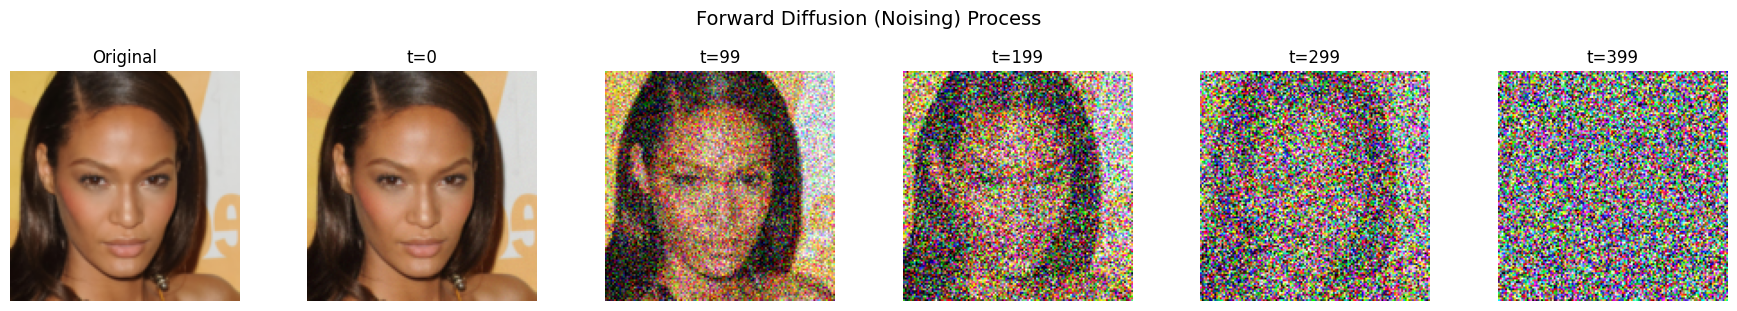

In [15]:
def unnormalize(t):
    """[-1,1] → [0,1]"""
    return (t.clamp(-1, 1) + 1) / 2

def show_forward_diffusion(dataset, diffusion, steps=5):
    x0 = dataset[0].unsqueeze(0).to(device)  # (1, C, H, W)
    timesteps = torch.linspace(0, cfg.T - 1, steps).long()

    fig, axes = plt.subplots(1, steps + 1, figsize=(3 * (steps + 1), 3))
    axes[0].imshow(unnormalize(x0[0]).cpu().permute(1, 2, 0))
    axes[0].set_title('Original')
    axes[0].axis('off')

    for i, t in enumerate(timesteps):
        t_batch = t.unsqueeze(0).to(device)
        x_noisy, _ = diffusion.q_sample(x0, t_batch)
        axes[i + 1].imshow(unnormalize(x_noisy[0]).cpu().permute(1, 2, 0))
        axes[i + 1].set_title(f't={t.item()}')
        axes[i + 1].axis('off')

    plt.suptitle('Forward Diffusion (Noising) Process', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{cfg.SAVE_DIR}/forward_diffusion.png', bbox_inches='tight', dpi=150)
    plt.show()

show_forward_diffusion(train_dataset, diffusion, steps=5)

## 5. U-Net Architecture (Part 3 – Reverse Process)

In [16]:
# ─────────────────────────────────────────────
# Time-step Sinusoidal Embedding
# ─────────────────────────────────────────────
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
        )
        args  = t[:, None].float() * freqs[None]
        emb   = torch.cat([args.sin(), args.cos()], dim=-1)
        return emb  # (B, dim)


# ─────────────────────────────────────────────
# Residual Block with Time Conditioning
# ─────────────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, dropout=0.1):
        super().__init__()
        self.norm1   = nn.GroupNorm(8, in_ch)
        self.conv1   = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2   = nn.GroupNorm(8, out_ch)
        self.conv2   = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.dropout = nn.Dropout(dropout)
        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch * 2),  # scale+shift
        )
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        # Inject time: scale & shift
        t_out = self.time_proj(t_emb)[:, :, None, None]
        scale, shift = t_out.chunk(2, dim=1)
        h = self.norm2(h) * (1 + scale) + shift
        h = self.dropout(self.conv2(F.silu(h)))
        return h + self.skip(x)


# ─────────────────────────────────────────────
# Attention Block (Self-Attention at lower res)
# ─────────────────────────────────────────────
class AttentionBlock(nn.Module):
    def __init__(self, ch, num_heads=4):
        super().__init__()
        self.norm  = nn.GroupNorm(8, ch)
        self.attn  = nn.MultiheadAttention(ch, num_heads, batch_first=True)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x).view(B, C, H * W).permute(0, 2, 1)  # (B, HW, C)
        h, _ = self.attn(h, h, h)
        return x + h.permute(0, 2, 1).view(B, C, H, W)


# ─────────────────────────────────────────────
# Down / Up sampling
# ─────────────────────────────────────────────
class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 4, stride=2, padding=1)
    def forward(self, x): return self.conv(x)

class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.ConvTranspose2d(ch, ch, 4, stride=2, padding=1)
    def forward(self, x): return self.conv(x)


# ─────────────────────────────────────────────
# U-Net Backbone
# ─────────────────────────────────────────────
class UNet(nn.Module):
    """
    Simplified U-Net with:
      - Sinusoidal time embeddings
      - Residual blocks with time conditioning
      - Self-attention at bottleneck
      - Channel progression: 64 → 128 → 256
    """
    def __init__(self, in_ch=3, base_ch=64, time_emb_dim=256):
        super().__init__()
        ch = base_ch  # 64

        # Time embedding MLP
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(ch),
            nn.Linear(ch, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        td = time_emb_dim

        # ── Encoder ──
        self.init_conv = nn.Conv2d(in_ch, ch, 3, padding=1)       # 64

        self.down1a = ResBlock(ch,      ch,      td)               # 64→64
        self.down1b = ResBlock(ch,      ch,      td)
        self.pool1  = Downsample(ch)

        self.down2a = ResBlock(ch,      ch*2,    td)               # 64→128
        self.down2b = ResBlock(ch*2,    ch*2,    td)
        self.pool2  = Downsample(ch*2)

        self.down3a = ResBlock(ch*2,    ch*4,    td)               # 128→256
        self.down3b = ResBlock(ch*4,    ch*4,    td)
        self.pool3  = Downsample(ch*4)

        # ── Bottleneck ──
        self.mid1   = ResBlock(ch*4, ch*4, td)
        self.mid_attn = AttentionBlock(ch*4)
        self.mid2   = ResBlock(ch*4, ch*4, td)

        # ── Decoder ──
        self.up3    = Upsample(ch*4)
        self.upb3a  = ResBlock(ch*8,    ch*4,    td)               # concat skip → 512
        self.upb3b  = ResBlock(ch*4,    ch*4,    td)

        self.up2    = Upsample(ch*4)
        self.upb2a  = ResBlock(ch*6,    ch*2,    td)               # 256+128=384 → concat
        self.upb2b  = ResBlock(ch*2,    ch*2,    td)

        self.up1    = Upsample(ch*2)
        self.upb1a  = ResBlock(ch*3,    ch,      td)               # 128+64=192
        self.upb1b  = ResBlock(ch,      ch,      td)

        # ── Output ──
        self.out_norm = nn.GroupNorm(8, ch)
        self.out_conv = nn.Conv2d(ch, in_ch, 1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)           # (B, td)

        # Encoder
        x0 = self.init_conv(x)             # (B, 64, H, W)
        x1 = self.down1b(self.down1a(x0, t_emb), t_emb)   # (B, 64, H, W)
        x2 = self.down2b(self.down2a(self.pool1(x1), t_emb), t_emb)  # (B,128,H/2,W/2)
        x3 = self.down3b(self.down3a(self.pool2(x2), t_emb), t_emb)  # (B,256,H/4,W/4)

        # Bottleneck
        m = self.pool3(x3)                 # (B,256,H/8,W/8)
        m = self.mid2(self.mid_attn(self.mid1(m, t_emb)), t_emb)

        # Decoder with skip connections
        m = self.upb3b(self.upb3a(torch.cat([self.up3(m), x3], dim=1), t_emb), t_emb)
        m = self.upb2b(self.upb2a(torch.cat([self.up2(m), x2], dim=1), t_emb), t_emb)
        m = self.upb1b(self.upb1a(torch.cat([self.up1(m), x1], dim=1), t_emb), t_emb)

        return self.out_conv(F.silu(self.out_norm(m)))  # (B, 3, H, W)


# Instantiate model (multi-GPU support)
model = UNet(in_ch=cfg.CHANNELS, base_ch=cfg.MODEL_CHANNELS, time_emb_dim=cfg.TIME_EMB_DIM)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'U-Net parameters: {total_params:,}')

U-Net parameters: 14,660,419


## 6. Training (Part 4)

In [17]:
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)
scaler    = GradScaler(enabled=cfg.AMP)
mse_loss  = nn.MSELoss()

train_losses = []

def train_one_epoch(model, loader, epoch):
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{cfg.EPOCHS}')

    for x0 in pbar:
        x0 = x0.to(device, non_blocking=True)
        B  = x0.shape[0]

        # Sample random timesteps
        t = torch.randint(0, cfg.T, (B,), device=device)

        # Forward process: add noise
        noise = torch.randn_like(x0)
        x_t, _ = diffusion.q_sample(x0, t, noise)

        # Reverse process: predict noise
        with autocast(enabled=cfg.AMP):
            eps_pred = model(x_t, t)
            loss     = mse_loss(eps_pred, noise)

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return epoch_loss / len(loader)


print('Starting training...')
for epoch in range(cfg.EPOCHS):
    avg_loss = train_one_epoch(model, train_loader, epoch)
    train_losses.append(avg_loss)
    scheduler.step()
    print(f'Epoch {epoch+1:3d} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}')

    # Save checkpoint every 5 epochs
    if (epoch + 1) % 5 == 0:
        torch.save({
            'epoch': epoch,
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'losses': train_losses,
        }, cfg.CKPT_PATH)
        print(f'  Checkpoint saved → {cfg.CKPT_PATH}')

print('Training complete!')

Starting training...


/tmp/ipykernel_57/1696756932.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=cfg.AMP)


Epoch 1/10:   0%|          | 0/1687 [00:00<?, ?it/s]

/tmp/ipykernel_57/1696756932.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.AMP):


Epoch   1 | Loss: 0.0493 | LR: 0.000195


...

Epoch   8 | Loss: 0.0226 | LR: 0.000019


Epoch 9/10:   0%|          | 0/1687 [00:00<?, ?it/s]

Epoch   9 | Loss: 0.0224 | LR: 0.000005


Epoch 10/10:   0%|          | 0/1687 [00:00<?, ?it/s]

Epoch  10 | Loss: 0.0226 | LR: 0.000000
  Checkpoint saved → ./ddpm_checkpoint.pt
Training complete!


### Training Loss Plot

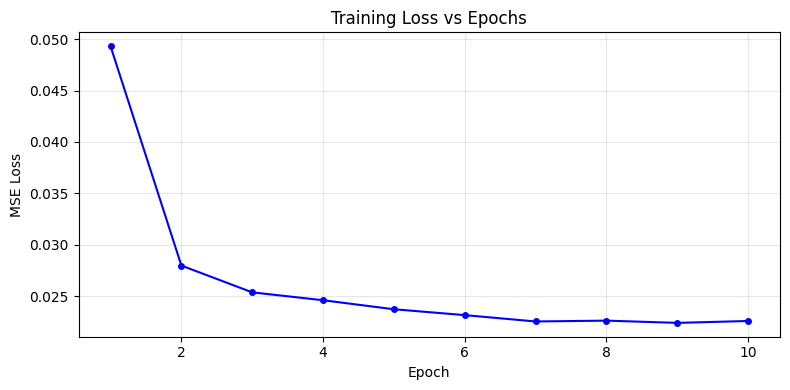

Final loss: 0.0226


In [18]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss vs Epochs')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{cfg.SAVE_DIR}/training_loss.png', dpi=150)
plt.show()
print(f'Final loss: {train_losses[-1]:.4f}')

## 7. Image Generation – 5 New Images from Pure Noise (Part 6)

Sampling:   0%|          | 0/400 [00:00<?, ?it/s]

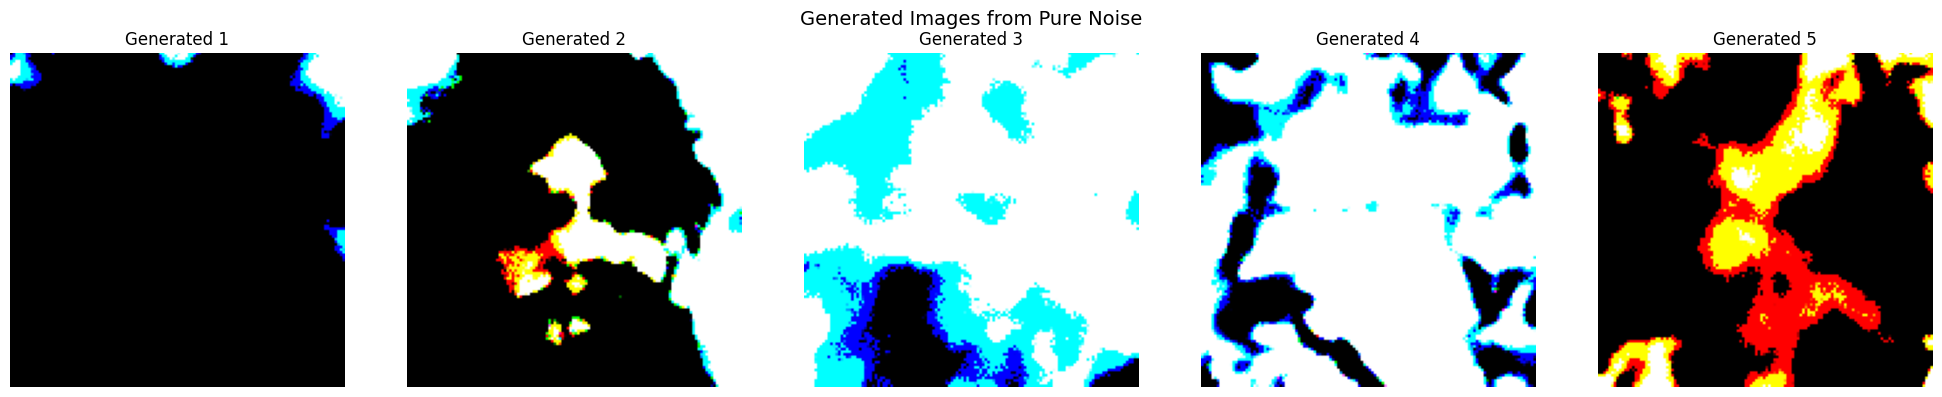

Saved 5 generated images to ./outputs/


In [19]:
model.eval()
N_GEN = 5
shape = (N_GEN, cfg.CHANNELS, cfg.IMG_SIZE, cfg.IMG_SIZE)

gen_images, intermediates = diffusion.sample(model, shape, return_intermediates=True)
gen_images = unnormalize(gen_images).cpu()

# Display
fig, axes = plt.subplots(1, N_GEN, figsize=(4 * N_GEN, 4))
for i in range(N_GEN):
    axes[i].imshow(gen_images[i].permute(1, 2, 0).numpy().clip(0, 1))
    axes[i].set_title(f'Generated {i+1}')
    axes[i].axis('off')
plt.suptitle('Generated Images from Pure Noise', fontsize=14)
plt.tight_layout()
plt.savefig(f'{cfg.SAVE_DIR}/generated_images.png', dpi=150, bbox_inches='tight')
plt.show()

# Save individually
for i, img in enumerate(gen_images):
    save_image(img, f'{cfg.SAVE_DIR}/gen_{i+1}.png')
print(f'Saved {N_GEN} generated images to {cfg.SAVE_DIR}/')

## 8. Image Reconstruction Task (Part 5 – CORE)

Sampling:   0%|          | 0/400 [00:00<?, ?it/s]

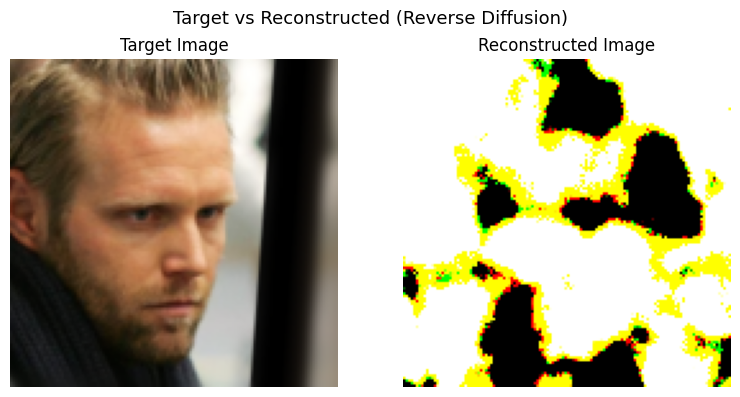

Reconstruction done.


In [20]:
# ── Pick a target image from the VALIDATION set ──
# valid/ is used here because it contains held-out images the model
# has never trained on — making reconstruction a fairer evaluation.
target_idx   = 0
target_img   = valid_dataset[target_idx].unsqueeze(0).to(device)   # (1, C, H, W)

# ── Reconstruct: start from noise, run full reverse diffusion ──
recon_image, recon_intermediates = diffusion.sample(
    model,
    shape=(1, cfg.CHANNELS, cfg.IMG_SIZE, cfg.IMG_SIZE),
    return_intermediates=True,
)

target_np = unnormalize(target_img[0]).cpu().permute(1, 2, 0).numpy().clip(0, 1)
recon_np  = unnormalize(recon_image[0]).cpu().permute(1, 2, 0).numpy().clip(0, 1)

# ── Side-by-side comparison ──
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(target_np)
axes[0].set_title('Target Image')
axes[0].axis('off')
axes[1].imshow(recon_np)
axes[1].set_title('Reconstructed Image')
axes[1].axis('off')
plt.suptitle('Target vs Reconstructed (Reverse Diffusion)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{cfg.SAVE_DIR}/reconstruction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Reconstruction done.')

## 9. Quantitative Evaluation – PSNR & SSIM (Part 4 Deliverable)

In [21]:
def compute_metrics(img1_np, img2_np):
    """
    img1_np, img2_np: HxWx3 numpy arrays in [0,1]
    Returns PSNR (dB) and SSIM.
    """
    p = psnr(img1_np, img2_np, data_range=1.0)
    s = ssim(img1_np, img2_np, data_range=1.0, channel_axis=2)
    return p, s

psnr_val, ssim_val = compute_metrics(target_np, recon_np)
print(f'─── Quantitative Evaluation ───')
print(f'PSNR : {psnr_val:.2f} dB')
print(f'SSIM : {ssim_val:.4f}')
print()
print('Note: DDPM generates diverse outputs, so direct target↔reconstruction')
print('metrics reflect diversity rather than exact pixel-level fidelity.')

# Also compute average PSNR/SSIM across N generated images vs random real images
gen_psnrs, gen_ssims = [], []
for i in range(min(N_GEN, len(valid_dataset))):
    real_np = unnormalize(valid_dataset[i]).permute(1, 2, 0).numpy().clip(0, 1)
    g_np    = unnormalize(diffusion.sample(
        model, (1, cfg.CHANNELS, cfg.IMG_SIZE, cfg.IMG_SIZE)
    )[0]).cpu().permute(1, 2, 0).numpy().clip(0, 1)
    p_, s_  = compute_metrics(real_np, g_np)
    gen_psnrs.append(p_)
    gen_ssims.append(s_)

print(f'\nAvg PSNR (gen vs real): {np.mean(gen_psnrs):.2f} dB')
print(f'Avg SSIM (gen vs real): {np.mean(gen_ssims):.4f}')

─── Quantitative Evaluation ───
PSNR : 3.78 dB
SSIM : 0.1120

Note: DDPM generates diverse outputs, so direct target↔reconstruction
metrics reflect diversity rather than exact pixel-level fidelity.


Sampling:   0%|          | 0/400 [00:00<?, ?it/s]

Sampling:   0%|          | 0/400 [00:00<?, ?it/s]

Sampling:   0%|          | 0/400 [00:00<?, ?it/s]

Sampling:   0%|          | 0/400 [00:00<?, ?it/s]

Sampling:   0%|          | 0/400 [00:00<?, ?it/s]


Avg PSNR (gen vs real): 5.01 dB
Avg SSIM (gen vs real): 0.1386


## 10. Visualization Module (Part 4 Deliverable)

Sampling:   0%|          | 0/400 [00:00<?, ?it/s]

Sampling:   0%|          | 0/400 [00:00<?, ?it/s]

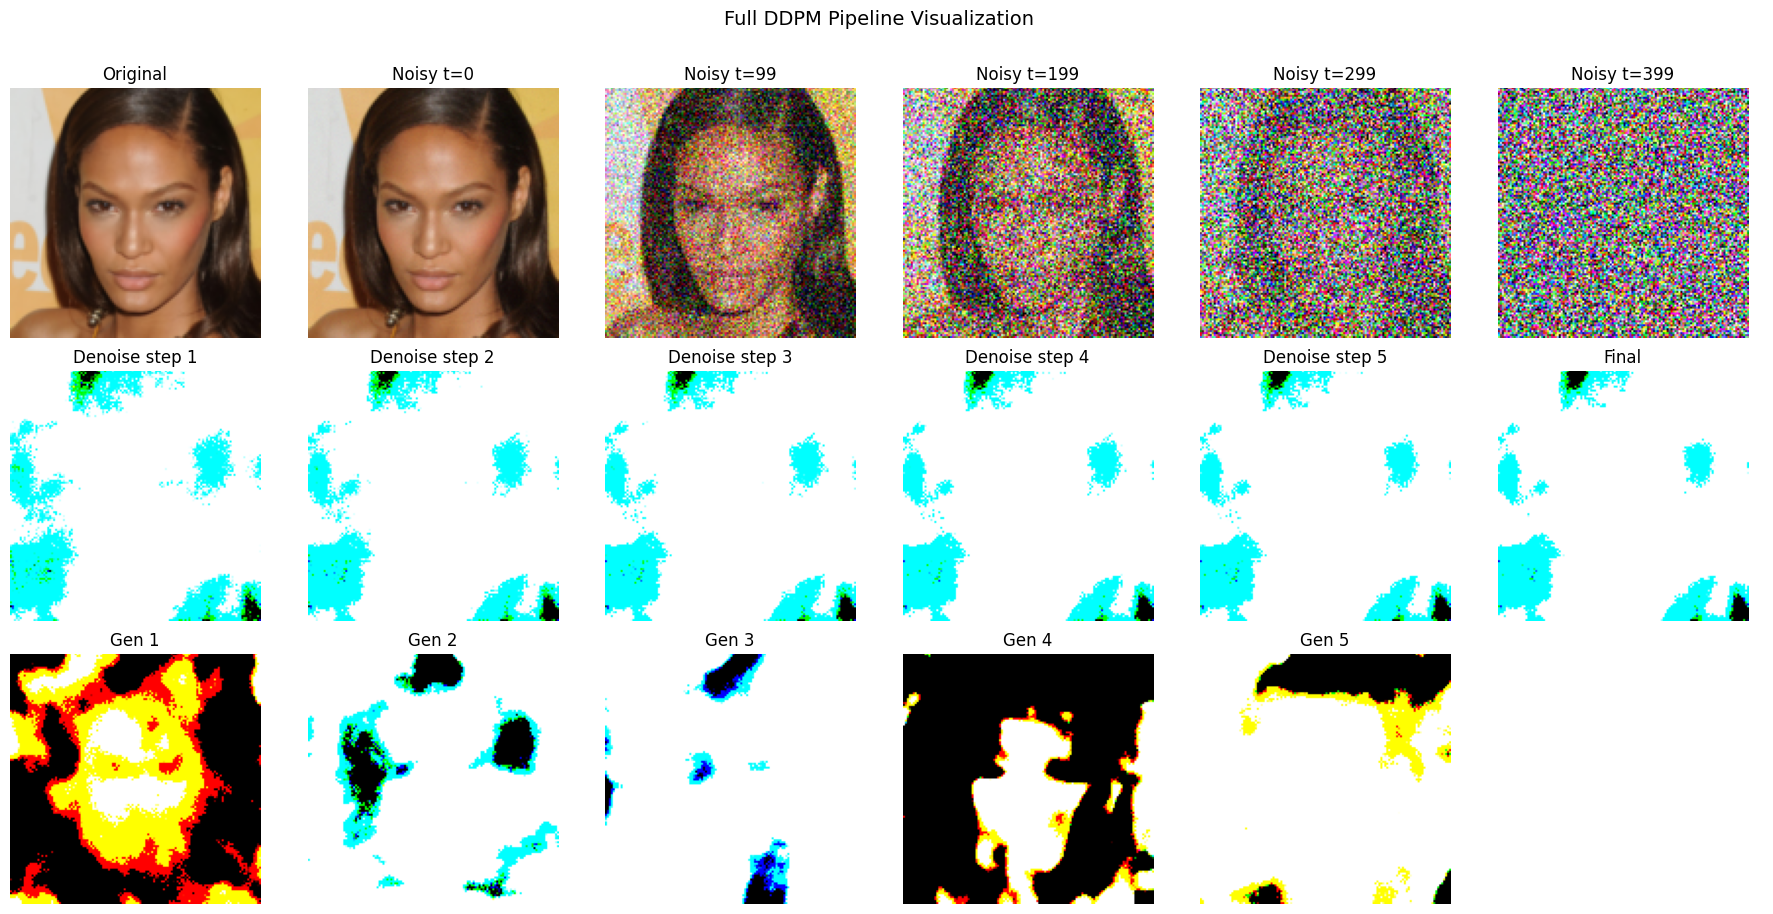

In [22]:
def visualize_full_pipeline(dataset, model, diffusion, n_forward=5, n_reverse=5, n_gen=5):
    """
    Shows:
      Row 1: Original + n_forward noising steps
      Row 2: n_reverse denoising steps (from pure noise)
      Row 3: n_gen new generated images
    """
    fig, axes = plt.subplots(3, max(n_forward, n_reverse, n_gen) + 1,
                              figsize=(3 * (n_forward + 1), 9))

    # ── Row 1: Forward diffusion ──
    x0 = dataset[0].unsqueeze(0).to(device)
    ts = torch.linspace(0, cfg.T - 1, n_forward).long()
    axes[0, 0].imshow(unnormalize(x0[0]).cpu().permute(1, 2, 0))
    axes[0, 0].set_title('Original')
    for i, t in enumerate(ts):
        xt, _ = diffusion.q_sample(x0, t.unsqueeze(0).to(device))
        axes[0, i + 1].imshow(unnormalize(xt[0]).cpu().permute(1, 2, 0))
        axes[0, i + 1].set_title(f'Noisy t={t.item()}')

    # ── Row 2: Reverse diffusion intermediates ──
    _, ints = diffusion.sample(
        model, (1, cfg.CHANNELS, cfg.IMG_SIZE, cfg.IMG_SIZE),
        return_intermediates=True
    )
    # ints contains ~10 snapshots; pick n_reverse of them
    step_ints = ints[:n_reverse] if len(ints) >= n_reverse else ints
    for j, im in enumerate(step_ints):
        axes[1, j].imshow(unnormalize(im[0]).cpu().permute(1, 2, 0).clamp(0, 1))
        axes[1, j].set_title(f'Denoise step {j+1}')
    # Final
    axes[1, len(step_ints)].imshow(
        unnormalize(ints[-1][0]).cpu().permute(1, 2, 0).clamp(0, 1))
    axes[1, len(step_ints)].set_title('Final')

    # ── Row 3: Fresh generated images ──
    gens = diffusion.sample(model, (n_gen, cfg.CHANNELS, cfg.IMG_SIZE, cfg.IMG_SIZE))
    for k in range(n_gen):
        axes[2, k].imshow(unnormalize(gens[k]).cpu().permute(1, 2, 0).clamp(0, 1))
        axes[2, k].set_title(f'Gen {k+1}')

    # Clean up extra axes
    for row in axes:
        for ax in row:
            ax.axis('off')

    row_labels = ['Forward Diffusion (Noising)', 'Reverse Diffusion (Denoising)', 'Generated Images']
    for i, label in enumerate(row_labels):
        axes[i, 0].set_ylabel(label, fontsize=10, rotation=90, labelpad=10)
        axes[i, 0].axis('off')

    plt.suptitle('Full DDPM Pipeline Visualization', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{cfg.SAVE_DIR}/full_pipeline_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()


visualize_full_pipeline(train_dataset, model, diffusion)

## 11. Gradio App Deployment (Part 5 Deliverable)

In [ ]:
import gradio as gr
import numpy as np

def generate_image_gradio(seed: int, show_steps: bool):
    """
    Gradio callback: generates one image from pure noise.
    Returns final image + optionally a grid of intermediate steps.
    """
    torch.manual_seed(int(seed))
    model.eval()

    shape = (1, cfg.CHANNELS, cfg.IMG_SIZE, cfg.IMG_SIZE)
    x, ints = diffusion.sample(model, shape, return_intermediates=True)

    final = (unnormalize(x[0]).cpu().permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)

    if show_steps and len(ints) > 0:
        step_imgs = []
        for im in ints:
            np_im = (unnormalize(im[0]).cpu().permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)
            step_imgs.append(np_im)
        # Horizontal concat
        grid = np.concatenate(step_imgs, axis=1)
        return final, grid
    return final, None


with gr.Blocks(title='DDPM Image Generator') as demo:
    gr.Markdown('# 🎨 DDPM Image Generator\nGenerates a face image from **pure Gaussian noise** using a trained Denoising Diffusion Probabilistic Model.')

    with gr.Row():
        seed_input  = gr.Number(label='Random Seed', value=42, precision=0)
        steps_check = gr.Checkbox(label='Show Intermediate Denoising Steps', value=True)

    btn = gr.Button('Generate Image 🚀', variant='primary')

    with gr.Row():
        out_final = gr.Image(label='Generated Image', type='numpy')
        out_steps = gr.Image(label='Intermediate Steps', type='numpy')

    btn.click(
        fn=generate_image_gradio,
        inputs=[seed_input, steps_check],
        outputs=[out_final, out_steps],
    )

demo.launch(share=True, debug=True)

## 12. Bonus – DDIM Accelerated Sampling
> Implements faster sampling with fewer steps (DDIM, Song et al. 2020)

DDIM sampling (50 steps)...


DDIM Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

DDIM time: 2.2s


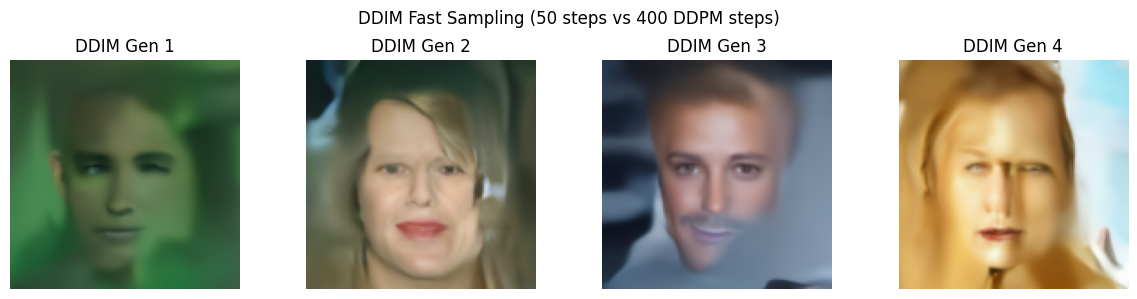

In [23]:
class DDIMSampler:
    """
    Denoising Diffusion Implicit Models (DDIM) — faster sampling.
    Uses a subset of timesteps (ddim_steps) instead of the full T.
    """
    def __init__(self, diffusion: GaussianDiffusion, ddim_steps: int = 50, eta: float = 0.0):
        self.diffusion  = diffusion
        self.ddim_steps = ddim_steps
        self.eta        = eta   # 0 = deterministic, 1 = stochastic (== DDPM)
        # Select a subset of timesteps evenly spaced
        step_size = diffusion.T // ddim_steps
        self.timesteps = list(reversed(range(0, diffusion.T, step_size)))[:ddim_steps]

    @torch.no_grad()
    def sample(self, model, shape):
        model.eval()
        x = torch.randn(shape, device=device)
        dif = self.diffusion

        for i, t_cur in enumerate(tqdm(self.timesteps, desc='DDIM Sampling')):
            t_prev = self.timesteps[i + 1] if i + 1 < len(self.timesteps) else 0
            t_b    = torch.full((shape[0],), t_cur, device=device, dtype=torch.long)

            eps = model(x, t_b)

            ab_t  = dif.alpha_bar[t_cur]
            ab_tp = dif.alpha_bar[t_prev]

            # Predict x0
            x0_pred = (x - (1 - ab_t).sqrt() * eps) / ab_t.sqrt()
            x0_pred = x0_pred.clamp(-1, 1)

            # Direction pointing to x_t
            sigma   = self.eta * ((1 - ab_tp) / (1 - ab_t) * (1 - ab_t / ab_tp)).sqrt()
            dir_xt  = (1 - ab_tp - sigma**2).sqrt() * eps

            noise = torch.randn_like(x) if self.eta > 0 else 0
            x = ab_tp.sqrt() * x0_pred + dir_xt + sigma * noise

        return x


# Compare speed
import time

ddim = DDIMSampler(diffusion, ddim_steps=50, eta=0.0)

print('DDIM sampling (50 steps)...')
t0 = time.time()
ddim_imgs = ddim.sample(model, (4, cfg.CHANNELS, cfg.IMG_SIZE, cfg.IMG_SIZE))
print(f'DDIM time: {time.time() - t0:.1f}s')

ddim_imgs = unnormalize(ddim_imgs).cpu()
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(ddim_imgs[i].permute(1, 2, 0).clamp(0, 1))
    axes[i].set_title(f'DDIM Gen {i+1}')
    axes[i].axis('off')
plt.suptitle('DDIM Fast Sampling (50 steps vs 400 DDPM steps)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{cfg.SAVE_DIR}/ddim_generated.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
from IPython.display import FileLink

# Generate a download link for the checkpoint file
FileLink('ddpm_checkpoint.pt')

/kaggle/working/ddpm_checkpoint.pt